# Deep Learning Foundations

Welcome to Deep Learning! In this class, you’ll learn how modern deep learning models work under the hood by building and training neural networks from scratch. We’ll start by implementing a simple deep learning model using only NumPy to understand the core mechanics of neural networks. By the end of this course you’ll be able to build, tune, and debug deep learning models using PyTorch.

## What is a Neural Network?

In your previous ML class, you learned models like:
- **Lasso / Ridge** - linear regression
- **Decision Trees** - rule based models
- **KNN** - distance based classification

These models are powerful and useful, however they also have this in common:

- They require us to **design features** that make the problem easier to solve
- The model itself has **limited flexibility**, it can't be easily modified (despite hyper parameters)

## What Makes Networks Different?

Instead of us designing features by hand, neural networks can learn useful patterns directly from the data (once we do some basic cleanup). Instead of using a fixed structure like a tree or a linear model, they stack many **simple layers** to build more **complex behaviors**. If many of these these layers are stacked together you get a **deep network**.

Here is what our simple layer looks like.

1. **Linear transform:** Z = WX + b

   - This is a **weighted sum of the inputs** plus a bias term
   - "Linear" here means that this transformation can only model straight line relationships
   - If you stacked only linear layers, your network would still be equivalent to a single linear transformation

2. **Non linear transform:** A = activation(Z)

   - To break out of this limitation, we apply a **non linear activation function**
   - Non linearity allows the network to learn **curves, bends, and complex relationships**
   - Different functions are better at certain tasks, we'll discuss how to pick one another time

### Non Linearity

That might sound complicated, but we can actually achieve it with some basic numpy. Here’s what some of these functions actually look like.

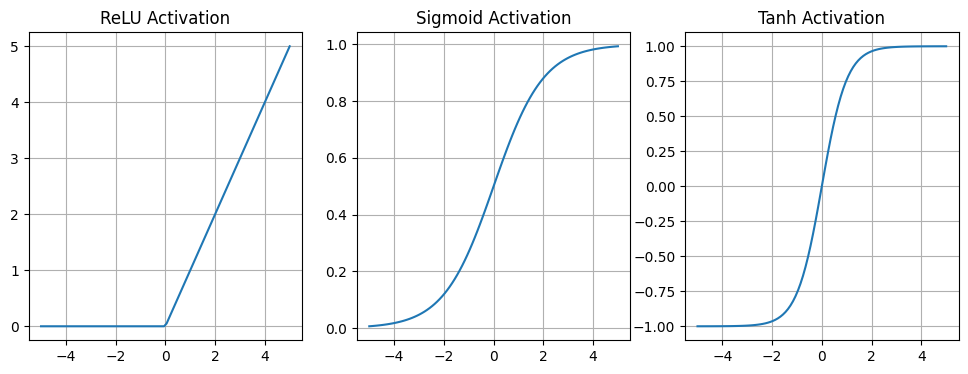

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 100)

relu = np.maximum(0, x)
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(x, relu)
plt.title("ReLU Activation")
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(x, sigmoid)
plt.title("Sigmoid Activation")
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(x, tanh)
plt.title("Tanh Activation")
plt.grid(True)

plt.show()

## The "Neuron" of Neural Networks

Each of these simple building blocks is performed by a **neuron** in the network. A neuron is just a small computational unit that performs these steps on its inputs. By stacking layers of neurons, the network can learn complex functions. In a biological brain, a **neuron** is a cell that processes and transmits information. In a **neural network**, a neuron is a simple **computational unit** that does the following:

1. It takes in one or more **input values**
2. It applies a **weighted sum** to those inputs: Z = W X + b
3. It passes the result through a **nonlinear activation function** to produce an output: A = activation(Z)

The neuron's job is to compute one **number** based on its inputs. That number becomes input to neurons in the next layer.

<img src="imgs/img-01.png" alt="Neuron Example" style="width:40%;"/>

### How Do We Choose the Weights?

When we first build a neural network, we don’t yet know what the weights should be, so we **start with random values**. This gives each neuron a slightly different behavior at the start, so they can learn different things during training. If all weights were the same, every neuron would behave identically and the network wouldn’t learn effectively. The model learns by simply changing these weights!

## Types of Neural Networks

"Neural network" is a general term, it refers to a large family of models that all share the same basic idea: they process data through layers of neurons. There are many different types of neural networks, each specialized for different kinds of data and tasks.

| Type | Architecture | Typical Use Case |
|------|--------------|------------------|
| **Perceptron** | Single layer, step function | Simple binary classification |
| **MLP** (Multi Layer Perceptron) | Fully connected layers | Tabular data |
| **CNN** (Convolutional Neural Network) | Convolutional layers | Image data |
| **Transformer** | Attention based layers | Language models |

## The Perceptron

Before we dive deeper into multilayer networks let’s look at the simplest possible neural model. The perceptron is a **building block** of a neural networks, in fact it’s just a **single neuron** that performs binary classification using a linear rule. The Perceptron is historically important and useful for understanding how a single neuron operates. Modern networks like MLPs, CNNs, and Transformers build on this foundation using deeper layers and non linear activation functions to handle much more complex patterns. They are to simple to be useful for modern tasks, but we can still learn a lot from analyzing this type of model.

### Training the Perceptron

Even though the perceptron is simple, it still follows the same structure as training modern models:
- Takes in an **input vector**
- Applies a **weighted sum** with a bias
- Passes the result through a **step function**
    - A perceptron stops here, but more complicated models continue from here

Since the weights are assigned randomly it is unlikely that we will make a good prediction initially. For the model to learn, weights are changed. We control the size of the weight changes using a **learning rate** (how aggressive are the changes). We repeat the process for **multiple epochs** (passes through the dataset). Changing the learning rate or number of epochs can affect how quickly the model learns and whether it converges to a good solution.

### Implementing the Perceptron

Now that we understand what a perceptron is and how it works, let’s implement one from scratch using NumPy.

- `__init__`:  
  Initializes the weights randomly, sets the bias to 0, and stores the learning rate

- `step(z)`:  
  A simple threshold activation function, returns 1 if the input is GTE 0, else 0

- `predict(x)`:  
  Computes the weighted sum plus bias for a single input and applies the step function to make a binary prediction

- `train(X, y, epochs)`:  
  Trains the model over multiple passes through the dataset, updates the weights and bias whenever a prediction is incorrect


In [3]:
import numpy as np

class Perceptron:
   
    def __init__(self, n_inputs, lr=0.1, seed=12345):
        """
        Constructor:
            self.W: weights, one for each input
            self.b: bias, one for the entire perceptron
            self.lr: learning rate
        """
        np.random.seed(seed)
        self.W = np.random.randn(n_inputs)
        self.b = 0.0
        self.lr = lr

    def activation(self, z):
        """
        Simulates the binary activation
        """
        return 1 if z >= 0 else 0 

    def predict(self, x):
        """
        Applies the linear transformation, then passes the result through activation
        """
        z = np.dot(self.W, x) + self.b
        return self.activation(z)

    def train(self, X, y, epochs=10):
        """
         Iterates through the dataset for a given number of epochs, updating the weights and bias
        """
        for _ in range(epochs):
            for xi, yi in zip(X, y):
                # Make prediction
                pred = self.predict(xi)

                # Compute prediction error
                error = yi - pred

                # Update all weights and bias
                self.W += self.lr * error * xi
                self.b += self.lr * error


### Testing the Perceptron

Now that we’ve built our perceptron, let’s try it out on a small dataset. We’ll use `make_blobs` from `sklearn.datasets` to generate **linearly separable data**, perfect for testing how well a perceptron can learn. The perceptron should find a linear decision boundary that separates the two clusters.

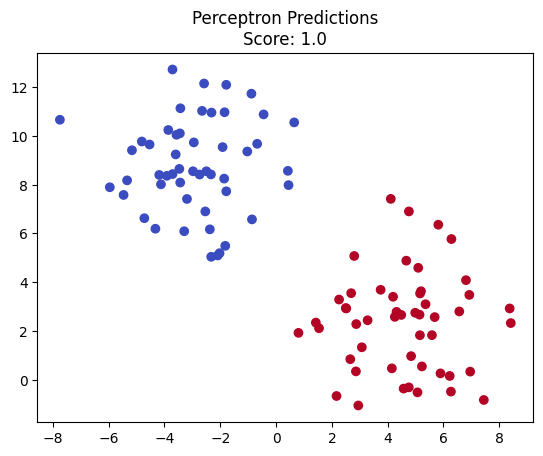

In [4]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Make linearly separable data
X, y = make_blobs(n_samples=100, centers=2, random_state=42, cluster_std=2)

# Train
model = Perceptron(n_inputs=2, lr=.1)
model.train(X, y, epochs=10)

# Predict
y_pred = np.array([model.predict(xi) for xi in X])

score = accuracy_score(y, y_pred)

# Validate
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap="coolwarm")
plt.title(f"Perceptron Predictions\nScore: {score}")
plt.show()


# Summary

This week we learned what a **neural network** is and how it compares to traditional machine learning models. We also focused on understanding the **core building blocks** of deep learning by creating a simple **perceptron** with numpy.

## Neural Networks

- A neural network is a model that transforms inputs
  - linear transform
  - non linear activation
- Types of Neural Networks
  - Perceptrons
  - MLP
  - CNN
  - Transformers

## Numpy Perceptron

- We built a basic perceptron model from scratch using only numpy
  - Implemented predictions using a weighted sum and a step function
  - Implemented **learning rate** and **epochs** to update weights and bias
  - Validating by examining preditions